# Import and Install Dependencies/Packages

In [ ]:
# -----------------------------------------------------------------------------------
# HIDDEN VARIABLES - enviornmental variables
# -----------------------------------------------------------------------------------
#!pip install python-dotenv --user --no-warn-script-location
from dotenv import load_dotenv

# -----------------------------------------------------------------------------------
# SPARK SESSION AND OPERATIONS
# -----------------------------------------------------------------------------------
from pyspark.sql import DataFrame, SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import hour, dayofweek, col, count, avg
from pyspark.sql import functions as F

# -----------------------------------------------------------------------------------
# DATA AND PYTHON
# -----------------------------------------------------------------------------------

# to capture the data from the URL's where the data is stored
#!pip install requests --user --no-warn-script-location
import os
import requests
from dateutil.relativedelta import relativedelta
from datetime import datetime
import time
from functools import reduce
import glob
import re
import pandas as pd


# -----------------------------------------------------------------------------------
# VISUALIZATIONS
# ----------------------------------------------------------------------------------- 
#!pip install plotly --user --no-warn-script-location
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# -----------------------------------------------------------------------------------
# GITIGNORE VARIABLES AND FILES
# -----------------------------------------------------------------------------------

# Username
load_dotenv() 
user = os.getenv('user')

# The folder where the data will be stored in the directory.
# Do not upload since it is a lot of data.
folder_name = 'taxi_data'
folder_name_zones = 'taxi_zone'

# Spark Session Variables and Build

In [3]:
# -----------------------------------------------------------------------------------
# SET THESE VALUES TO MATCH THE JUPYTER ENVIRONMENT
# -----------------------------------------------------------------------------------

# total cores
total_executor_cores = 8

# total memory/RAM allocated per node in GB
total_memory = 128

# set driver memory to 1-2GB for testing and development, 
# up to 4GB for production if necessary
driver_memory_reserve = 2

# -----------------------------------------------------------------------------------
# THESE VALUES WILL BE CALCULATED AUTOMATICALLY FROM THE VALUES SET ABOVE
# -----------------------------------------------------------------------------------

# reserve 1 core for the driver and rest for executors
executor_cores = total_executor_cores - 1

# amount of memory allocated for each executor
executor_memory = int((total_memory - driver_memory_reserve) / executor_cores)

# -----------------------------------------------------------------------------------
# BUILD THE SPARK SESSION
# -----------------------------------------------------------------------------------

spark = SparkSession.builder \
    .config("spark.driver.memory", f"{driver_memory_reserve}g") \
    .config("spark.executor.memory", f"{executor_memory}g") \
    .config('spark.executor.instances', executor_cores) \
    .getOrCreate()


# Extract, Transform, and Load data into a Spark Dataframe

In [4]:
# -----------------------------------------------------------------------------------
# IMPORT DATA
# -----------------------------------------------------------------------------------

# Capture the base URL and create a local folder to store the files.
# The base URL will be appended with the dates for the files we want to capture below.
base_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_'
base_path = f'/expanse/lustre/projects/uci157/{user}/nyc_taxi_surge_pricing/'
data_folder = f'{base_path}{folder_name}'

# If the folder doesn't exist, create it.
os.makedirs(data_folder, exist_ok=True)

# -----------------------------------------------------------------------------------
# Function to generate the date structure and range for the files we want to download
# Inputs:
# - start_date: datetime format of YYYY-MM-DD
# - end_date: datetime format of YYYY-MM-DD
# -----------------------------------------------------------------------------------
def url_date_gen(start_date, end_date):
    current_date = start_date
    while current_date <= end_date:
        yield current_date
        current_date += relativedelta(months=1)

# Define the start and end dates
start_date = datetime(2019,2,1)
end_date = datetime(2026,2,1)

# File counter to track if all files were downloaded already
file_counter = 0

# Download the files that contain the data.
for current_date in url_date_gen(start_date, end_date):
    
    # Format the date to be in the format that the URL uses: YYYY-MM.
    # Generate the URL path with the date.
    file_date = current_date.strftime('%Y-%m')
    file_name = f'High_Volume_Trip_Data_{file_date}.parquet'
    file_url = f'{base_url}{file_date}.parquet'
    file_path = os.path.join(data_folder, file_name)

    # Check if the file exists before attempting download.
    if os.path.exists(file_path):
        file_counter += 1 # add 1 if file is already downloaded
    else:
        # Use try and except to capture any issues.
        # Send a request to download the file.
        try:
            print(f'Downloading... {file_name} from {file_url}...')
            response = requests.get(file_url)
            response.raise_for_status()
    
            # If successful, write the content to a file in parquet.
            # Ensures it is written to disk and not just in memory.
            with open(file_path, 'wb') as file:
                file.write(response.content)
            print(f'Downloaded {file_name} successfully!')

            # Wait 5 seconds between each call.
            # Prevents denied requests if called to frequently.
            time.sleep(5)
    
        # If there are any issues, print an error message.
        except requests.exceptions.RequestException as e:
            print(f'Failed to download {file_name}: {e}')

# If all files were already downloaded, print a message to let user know.
# Otherwise say how many files were downloaded and skipped.
if file_counter == (end_date - start_date).days + 1:
    print('All files available. No additional files have been downloaded.')
else:
    print(f'{file_counter} files are already available and were skipped.')

85 files are already available and were skipped.


# Download the Taxi Zone Lookup Table

In [5]:
# Capture the base URL and create a local folder to store the files.
taxi_zone_lookup_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
taxi_zone_folder = f'{base_path}{folder_name_zones}'

# If the folder doesn't exist, create it.
os.makedirs(taxi_zone_folder, exist_ok=True)

# Set the file path and file name.
file_path = os.path.join(taxi_zone_folder, 'Taxi_Zone_Lookup.csv')

# File counter to track if all files were downloaded already
file_counter = 0

if os.path.exists(file_path):
    file_counter += 1 # add 1 if file is already downloaded
else:
    # Use try and except to capture any issues.
    # Send a request to download the file.
    try:
        print(f'Downloading... Taxi_Zone_Lookup.csv from {taxi_zone_lookup_url}...')
        response = requests.get(taxi_zone_lookup_url)
        response.raise_for_status()

        # If successful, write the content to a file in csv.
        # Ensures it is written to disk and not just in memory.
        with open(file_path, 'wb') as file:
            file.write(response.content)
        print(f'Downloaded Taxi_Zone_Lookup.csv successfully!')

    # If there are any issues, print an error message.
    except requests.exceptions.RequestException as e:
        print(f'Failed to download Taxi_Zone_Lookup.csv: {e}')

# If all files were already downloaded, print a message to let user know.
# Otherwise say how many files were downloaded and skipped.
if file_counter == 1:
    print('All files available. No additional files have been downloaded.')
else:
    print(f'{file_counter} files are already available and were skipped.')

All files available. No additional files have been downloaded.


#### After attmpting to perform some Spark Dataframe operations, it became obvious that there were data type mismatch issues with the parquet schemas over the years. In order to circumvent any issues with reading the data and performing operations, we will map the appropriate data types across all the files and merge. 

#### There was also an extra column added into the data beginning in 2025 so we will drop that column for all files that contain it for consistency.

In [6]:
# -----------------------------------------------------------------------------------
# DEFINE TARGET SCHEMA - the parquet schemas have mismatched types over the years.
# -----------------------------------------------------------------------------------
target_schema = {
    "hvfhs_license_num": StringType(),
    "dispatching_base_num": StringType(),
    "originating_base_num": StringType(),
    "request_datetime": TimestampType(),
    "on_scene_datetime": TimestampType(),
    "pickup_datetime": TimestampType(),
    "dropoff_datetime": TimestampType(),
    "PULocationID": LongType(),
    "DOLocationID": LongType(),
    "trip_miles": DoubleType(),
    "trip_time": LongType(),
    "base_passenger_fare": DoubleType(),
    "tolls": DoubleType(),
    "bcf": DoubleType(),
    "sales_tax": DoubleType(),
    "congestion_surcharge": DoubleType(),
    "airport_fee": DoubleType(),
    "tips": DoubleType(),
    "driver_pay": DoubleType(),
    "shared_request_flag": StringType(),
    "shared_match_flag": StringType(),
    "access_a_ride_flag": StringType(),
    "wav_request_flag": StringType(),
    "wav_match_flag": StringType()
}

# There is an extra column starting in 2025, we will drop this for consistency.
extra_cols_2025 = ["cbd_congestion_fee"]

# -----------------------------------------------------------------------------------
# Function to cast and drop extra column, returns a DataFrame
# Inputs:
# - df: is a DataFrame
# - schema_dict: is a dictionary with column names as keys and types as values
# - drop_columns: is a list of column names
# -----------------------------------------------------------------------------------
def cast_and_align(df: DataFrame, schema_dict: dict, drop_columns=None) -> DataFrame:
    # Drop the specific column.
    if drop_columns:
        cols_to_drop = [c for c in drop_columns if c in df.columns]
        if cols_to_drop:
            # Unpack all the columns, we only have 1
            df = df.drop(*cols_to_drop)
            # Uncomment print statement if testing for more columns in future.
            # print(f"Dropped columns: {cols_to_drop}")

    # Cast only existing columns, this will resolve any mismatch between the 
    # parquet schemas since there were issues when reading them in originally.
    for col_name, dtype in schema_dict.items():
        if col_name in df.columns:
            df = df.withColumn(col_name, col(col_name).cast(dtype))

    # Reorder columns to match schema, this will ensure unionByName works.
    df = df.select([c for c in schema_dict.keys() if c in df.columns])
    return df

# -----------------------------------------------------------------------------------
# Function to read and process files, returns a DataFrame
# Inputs:
# - folder_path: is the path to the folder as a string
# - schema_dict: is a dictionary with column names as keys and types as values
# - drop_columns: is a list of column names
# -----------------------------------------------------------------------------------
def read_and_process_all_files(folder_path: str, schema_dict: dict) -> DataFrame:
    # Glob is essentially a wildcard search for files, looking for parquet files.
    all_files = glob.glob(os.path.join(folder_path, "*.parquet"))
    dfs = []

    for f in all_files:
        df = spark.read.parquet(f) # read files one at a time

        # Drop extra columns only for files that are after the year 2024.
        # More years can be added here if processing at a later date.
        match = re.search(r'\d{4}', f) # finds year value 2024
        year = int(match.group()) if match else None
        if year and year > 2024:
            df = cast_and_align(df, schema_dict, drop_columns=extra_cols_2025)
        else:
            df = cast_and_align(df, schema_dict)

        dfs.append(df)

    # If there are no valid files in the folder, throw an exception.
    if not dfs:
        raise ValueError("No parquet files found in the folder...")

    # Merge all DataFrames.
    df_all = reduce(DataFrame.unionByName, dfs)
    return df_all

# -----------------------------------------------------------------------------------
# LOAD AND MERGE ALL DATA
# -----------------------------------------------------------------------------------
# folder_name was set previously, it is where the data was downloaded.
df = read_and_process_all_files(folder_name, target_schema)

# -----------------------------------------------------------------------------------
# VALIDATE BY CHECKING SCHEMA
# -----------------------------------------------------------------------------------
df.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp (nullable = true)
 |-- on_scene_datetime: timestamp (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_ride_flag: string (nul

#### To see the driver and executors that are running

In [7]:
# Run this cell after initializing SparkSession and loading in data.

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
df_exec = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
df_exec['maxMemory_GB'] = (df_exec['maxMemory'] / (1024**3)).round(2)
df_exec

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,8,1099746508,0,True,1.02


# Number of Observations

In [8]:
total_rows = df.count()
print('Total observations: {:,}'.format(total_rows))

Total observations: 1,521,319,081


# Check for Duplicates

In [9]:
# We will use pickup_datetime to see if there are duplicates.
# Since using distinct() would require a shuffle and we don't have distinct row identifiers.
column_name = "pickup_datetime"
column_df = df.select(column_name)

# Group by the column and count occurrences.
duplicate_check_df = column_df.groupBy(column_name).count()

# Filter for duplicates (count > 1).
duplicates_df = duplicate_check_df.filter(F.col("count") > 1)

# Sort by count in descending order.
sorted_duplicates_df = duplicates_df.orderBy(F.col("count").desc())

# Show duplicates.
sorted_duplicates_df.show()

+-------------------+-----+
|    pickup_datetime|count|
+-------------------+-----+
|2024-11-21 23:06:49|   81|
|2025-02-19 08:00:00|   65|
|2020-03-16 16:55:46|   65|
|2026-01-28 07:30:00|   64|
|2025-02-12 07:30:00|   63|
|2024-12-20 08:00:00|   63|
|2024-12-05 07:30:00|   62|
|2026-01-30 07:30:00|   62|
|2025-02-12 08:00:00|   61|
|2025-02-13 08:00:00|   59|
|2024-12-18 08:00:00|   59|
|2023-12-20 07:30:00|   59|
|2025-01-27 08:00:00|   59|
|2026-01-29 07:30:00|   58|
|2025-11-26 05:00:00|   58|
|2025-02-06 08:00:00|   57|
|2024-12-05 08:00:00|   57|
|2025-10-09 09:00:00|   57|
|2026-02-11 09:00:00|   57|
|2020-03-16 16:55:48|   56|
+-------------------+-----+
only showing top 20 rows



# Quick Stats on Numerical Columns

In [10]:
df.describe('trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 
                'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay').show(vertical=True)

-RECORD 0-----------------------------------
 summary              | count               
 trip_miles           | 1521319081          
 trip_time            | 1521319081          
 base_passenger_fare  | 1521319081          
 tolls                | 1521319081          
 bcf                  | 1521319081          
 sales_tax            | 1521319081          
 congestion_surcharge | 1520806040          
 airport_fee          | 1106884027          
 tips                 | 1521319081          
 driver_pay           | 1521319081          
-RECORD 1-----------------------------------
 summary              | mean                
 trip_miles           | 4.925552671920584   
 trip_time            | 1156.1247782890327  
 base_passenger_fare  | 23.03784450556322   
 tolls                | 1.0284985875525499  
 bcf                  | 0.6308308100167215  
 sales_tax            | 1.933033927899491   
 congestion_surcharge | 1.0174505226517907  
 airport_fee          | 0.19828769417231823 
 tips     

# Exploratory Data Analysis and Visualizations

## Surge Conditions - When are surge conditions more likely?

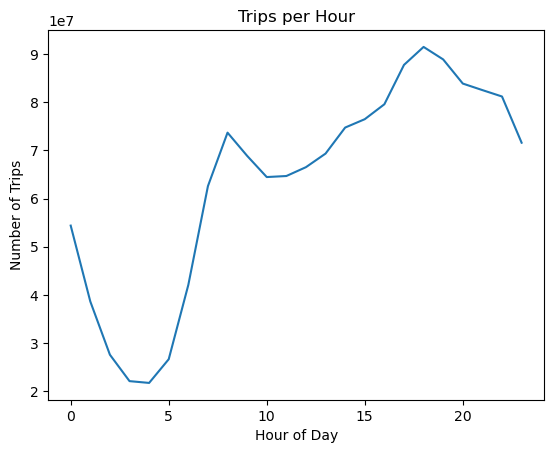

In [11]:
# Create a new column for requested pickup hour and pickup day of the week.
df = df.withColumn("request_hour", hour("request_datetime"))
df = df.withColumn("pickup_day_of_week", dayofweek("request_datetime")) # dayofweek starts with Sunday as 1

# Group by pickup hour and pickup day of the week to get counts.
hourly_demand = df.groupBy("request_hour").count().orderBy("request_hour")
day_of_week_demand = df.groupBy("pickup_day_of_week").count().orderBy("pickup_day_of_week")

# Create a folder to save the visualizations in.
image_folder = "visualizations"
os.makedirs(image_folder, exist_ok=True)

# Convert to a Pandas DF to plot a histogram.
hourly_pd_df = hourly_demand.toPandas()
plt.plot(hourly_pd_df['request_hour'], hourly_pd_df['count'])
plt.title("Trips per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

# Save the chart.
plt.savefig(f"{image_folder}/trips_per_hour.png", dpi=300, bbox_inches='tight')
plt.show()

plt.close()

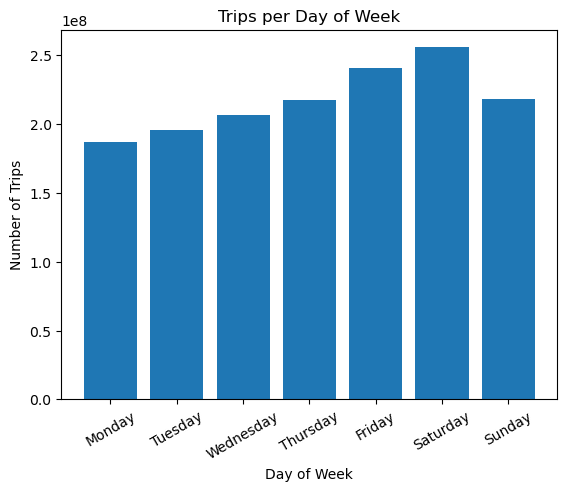

In [12]:
# Convert to a Pandas DF to plot a bar chart.
day_of_week_pd_df = day_of_week_demand.toPandas()

# Map the values to the day
day_names = {1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday", 7: "Saturday"}
day_of_week_pd_df['day_name'] = day_of_week_pd_df['pickup_day_of_week'].map(day_names)#.astype(str)

# Drop rows where mapping failed (NaN)
day_of_week_pd_df = day_of_week_pd_df.dropna(subset=['day_name'])

# Define the output order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Reorder the DataFrame accordingly
day_of_week_pd_df['day_name'] = pd.Categorical(day_of_week_pd_df['day_name'], categories=day_order, ordered=True)
day_of_week_pd_df = day_of_week_pd_df.sort_values('day_name')

#plt.figure(figsize=(10,6))
plt.bar(day_of_week_pd_df['day_name'], day_of_week_pd_df['count'])
plt.title("Trips per Day of Week")
plt.xlabel("Day of Week")
plt.xticks(rotation=30)
plt.ylabel("Number of Trips")

# Save the chart.
plt.savefig(f"{image_folder}/trips_per_day_of_week.png", dpi=300, bbox_inches='tight')
plt.show()

plt.close()

## Price Vs Distance - Are there unusual prices?

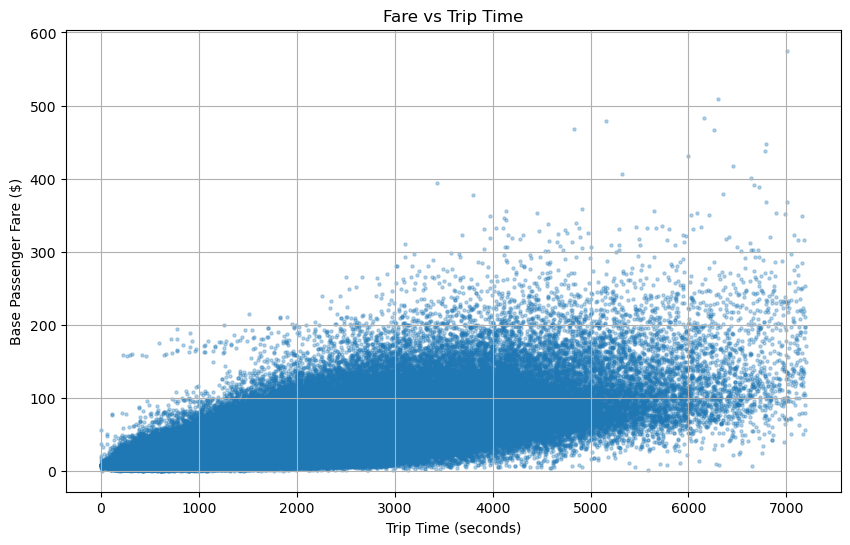

In [13]:
# Remove: trip time below 0 and above 7200 (2 hours), fare under 0, and cap miles at 100.
df_filtered_time = df.filter((col("trip_time") > 0) & (col("trip_time") <= 7200) & (col("base_passenger_fare") > 0) & (col("trip_miles") < 100))

# Take a sample of the data so we don't plot 1.5 billion points.
df_sample_time = df_filtered_time.sample(fraction=0.001, seed=24)

# Convert to Pandas for plotting
df_pd_time = df_sample_time.select("trip_time", "base_passenger_fare").toPandas()

plt.figure(figsize=(10,6))
plt.scatter(df_pd_time['trip_time'], df_pd_time['base_passenger_fare'], alpha=0.3, s=5)
plt.xlabel("Trip Time (seconds)")
plt.ylabel("Base Passenger Fare ($)")
plt.title("Fare vs Trip Time")
plt.grid(True)

# Save the chart.
plt.savefig(f"{image_folder}/fare_vs_trip_time.png", dpi=300, bbox_inches='tight')
plt.show()

plt.close()

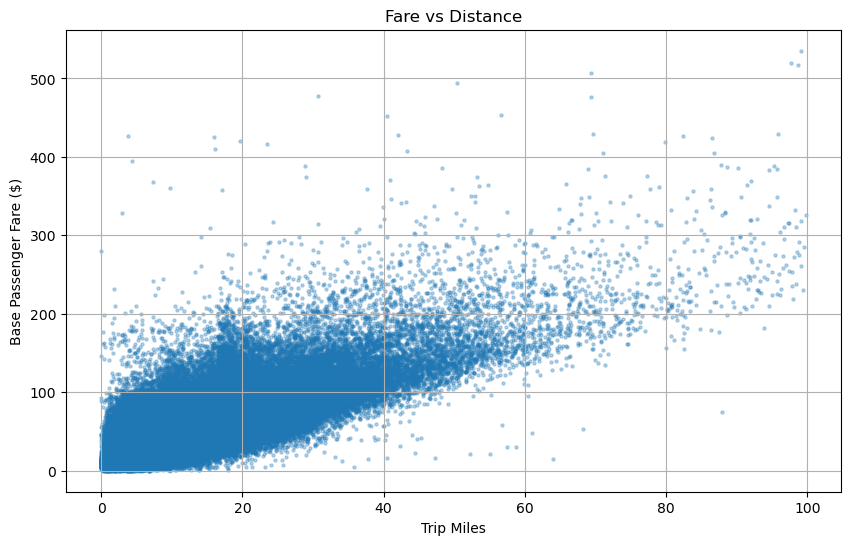

In [14]:
# Remove: trip miles under 0, fare under 0, and cap miles at 100.
df_filtered = df.filter((col("trip_miles") > 0) & (col("base_passenger_fare") > 0) & (col("trip_miles") < 100))

# Take a sample of the data so we don't plot 1.5 billion points.
df_sample = df_filtered.sample(fraction=0.001, seed=24)

# Convert to Pandas for plotting
df_pd = df_sample.select("trip_miles", "base_passenger_fare").toPandas()

plt.figure(figsize=(10,6))
plt.scatter(df_pd['trip_miles'], df_pd['base_passenger_fare'], alpha=0.3, s=5)
plt.xlabel("Trip Miles")
plt.ylabel("Base Passenger Fare ($)")
plt.title("Fare vs Distance")
plt.grid(True)

# Save the chart.
plt.savefig(f"{image_folder}/fare_vs_distance.png", dpi=300, bbox_inches='tight')
plt.show()

plt.close()

## Demand Vs Price - Is there a relationship here?

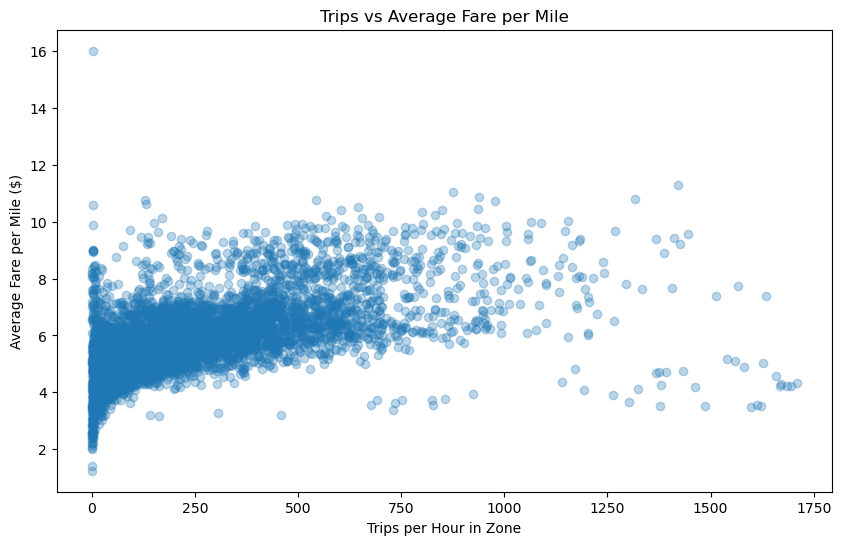

In [15]:
# Get the taxi zone lookup csv for mapping the zone names.
zone_lookup_df = pd.read_csv(f"{taxi_zone_folder}/Taxi_Zone_Lookup.csv")

# Remove: trip miles under 0, fare under 0, and cap miles at 100.
df_filtered_price = df.filter((col("trip_miles") > 0) & (col("base_passenger_fare") > 0) & (col("trip_miles") < 100))

# Take a sample of the data so we don't plot 1.5 billion points.
df_sample_price = df_filtered_price.sample(fraction=0.001, seed=24)

# Compute fare per mile.
df_price = df_sample_price.withColumn("fare_per_mile", col("base_passenger_fare") / col("trip_miles"))

# Sample with lower average.
df_price = df_price.filter((col("fare_per_mile") > 0) & (col("fare_per_mile") <= 50))

# Extract hour from pickup.
df_price = df_price.withColumn("pickup_hour", hour("pickup_datetime"))

# Count trips per zone per hour
demand_hour_zone = df_price.groupBy("PULocationID", "pickup_hour").count().withColumnRenamed("count", "trips")

# Average fare per mile per zone per hour
avg_fare_hour_zone = df_price.groupBy("PULocationID", "pickup_hour").agg(avg("fare_per_mile").alias("avg_fare_per_mile"))

# Join the trip counts with the average far per mile.
combined = demand_hour_zone.join(avg_fare_hour_zone, ["PULocationID", "pickup_hour"])

# Convert Spark DF to Pandas DF for plotting.
combined_pd_df = combined.toPandas()

# Map the names of the zones to make them more legible.
combined_pd_df = combined_pd_df.merge(zone_lookup_df, left_on="PULocationID", right_on="LocationID", how="left")


plt.figure(figsize=(10,6))
plt.scatter(combined_pd_df['trips'], combined_pd_df['avg_fare_per_mile'], alpha=0.3)
plt.xlabel("Trips per Hour in Zone")
plt.ylabel("Average Fare per Mile ($)")
plt.title("Trips vs Average Fare per Mile")

# Save the chart.
plt.savefig(f"{image_folder}/trips_vs_avg_fare_per_mile.png", dpi=300, bbox_inches='tight')
plt.show()

plt.close()

### Unique Employer Breakdown - Is there an even distribution or does one company have a majority?

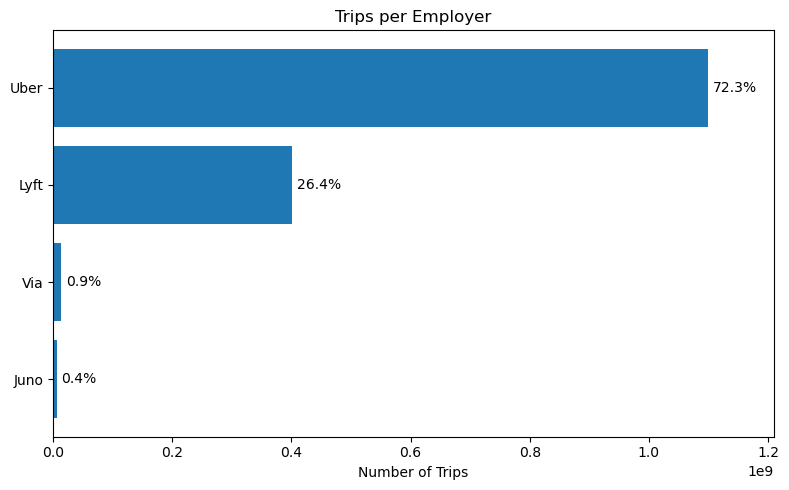

In [16]:
# Count trips per employer.
driver_counts = df.groupBy("hvfhs_license_num").agg(count("*").alias("num_trips"))

# Collect to Pandas DF for plotting.
driver_counts_pd_df = driver_counts.toPandas()

# Add the names from the data dictionary.
driver_counts_pd_df['business_name'] = driver_counts_pd_df['hvfhs_license_num'].map({
    "HV0002": "Juno",
    "HV0003": "Uber",
    "HV0004": "Via",
    "HV0005": "Lyft",
}).fillna("Unknown")

# Organize in ascending value.
driver_counts_pd_df = driver_counts_pd_df.sort_values('num_trips', ascending=True)

# Calculate the percentage of total trips to display.
total_trips = driver_counts_pd_df['num_trips'].sum()
driver_counts_pd_df['pct'] = driver_counts_pd_df['num_trips'] / total_trips * 100


plt.figure(figsize=(8,5))
bars = plt.barh(driver_counts_pd_df['business_name'], driver_counts_pd_df['num_trips'])

# Add some space to the x-axis so the percentage doesn't get cut off.
plt.xlim(0, driver_counts_pd_df['num_trips'].max() * 1.1)
plt.xlabel("Number of Trips")
plt.title("Trips per Employer")

# Add percentages to each bar.
for bar, pct in zip(bars, driver_counts_pd_df['pct']):
    width = bar.get_width()
    plt.text(width + total_trips*0.005, bar.get_y() + bar.get_height()/2, f"{pct:.1f}%", va='center')

plt.tight_layout()

# Save the chart.
plt.savefig(f"{image_folder}/trips_per_employer.png", dpi=300, bbox_inches='tight')
plt.show()

plt.close()

# Data Cleaning and Preprocessing

In [17]:
# We saw in the quick stats above that there are values that don't make sense.
# First we will clean up the df by removing rows that seem to be outside of normal operation.

# By checking the 99th percentile of each of these values, we can find an upper bound to cap off the data.
# For example, trip_miles for most trips, based on the mean and standard deviation, is most likely not over 100 miles (most likely less).
df.approxQuantile(
    ["trip_miles", "trip_time", "base_passenger_fare", "driver_pay"],
    [0.99, 0.999, 0.9999],
    0.001
)

[[26.09, 5380.78, 5380.78],
 [4094.0, 240764.0, 240764.0],
 [104.12, 8157.74, 8157.74],
 [77.56, 4894.62, 4894.62]]

The values for the 99th percentile indicate that we can use the following caps:
- trip_miles: 30 miles
- trip_time: 4500 seconds
- passenger_base_fare: 110 dollars
- driver_pay: 80 dollars

This gives us a bit of a buffer between the 99th percentile values and the cap. The 99.9th and 99.99th percentiles also are the same as the max values from the quick stats which means these might be erroneous values and should be removed anyways.

In [9]:
df_filtered = df.filter(
    (F.col("trip_miles") > 0.5) &            # exclude near zero/extremely short distances
    (F.col("trip_miles") <= 30) &            # exclude implausible long trips
    (F.col("trip_time") >= 60) &             # exclude trips less than 1 minute
    (F.col("trip_time") <= 4500) &           # exclude trips over 1 hour and 15 minutes (4500 seconds)
    (F.col("base_passenger_fare") > 0) &     # exclude zero and negative fares
    (F.col("base_passenger_fare") <= 110) &  # exclude fares over 110 dollars
    (F.col("driver_pay") > 0) &              # exclude zero and negative driver pay
    (F.col("driver_pay") <= 80)              # exclude driver pay over 80 dollars
)

In [10]:
# Checking to see if the values are more reasonable
df_filtered.describe('trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 
                'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay').show(vertical=True)

-RECORD 0-----------------------------------
 summary              | count               
 trip_miles           | 1442994591          
 trip_time            | 1442994591          
 base_passenger_fare  | 1442994591          
 tolls                | 1442994591          
 bcf                  | 1442994591          
 sales_tax            | 1442994591          
 congestion_surcharge | 1442496549          
 airport_fee          | 1070995741          
 tips                 | 1442994591          
 driver_pay           | 1442994591          
-RECORD 1-----------------------------------
 summary              | mean                
 trip_miles           | 4.616332063444499   
 trip_time            | 1117.8770179839157  
 base_passenger_fare  | 21.97286361170825   
 tolls                | 0.924002822421428   
 bcf                  | 0.6033619397544786  
 sales_tax            | 1.9001614154021544  
 congestion_surcharge | 1.0316072761363675  
 airport_fee          | 0.18437686625683788 
 tips     

Since we are going turn tolls, congestion_surcharge, and airport_fee into binary columns, the max values don't really matter here. Otherwise the maxes here do make sense but might need to be checked. sales_tax and bcf will be dropped so the values don't matter much here but good to check just to be safe. tips max value of 500 seems unreasonable for an average of ~$22 base fare so we will check the percentiles to see what is happening here.

In [11]:
df_filtered.approxQuantile(
    "tips",
    [0.95, 0.99, 0.999],
    0.001
)

[5.78, 12.52, 500.0]

In [12]:
# We can set a cap at 20 for tips since we see a similar pattern of the values jumping to the max value as before.
df_filtered = df_filtered.filter(F.col("tips") <= 20)

# Count the rows so we can check how many rows we lost, shouldn't be too many.
df_filtered.count()

1440693948

## Feature Engineering